# Análisis ConnectaTel

Evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajaremos con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

---
### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/content/plans.csv')
users = pd.read_csv('/content/users_latam.csv')
usage = pd.read_csv('/content/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
 # mostrar las primeras 5 filas de users
 users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
 # mostrar las primeras 5 filas de usage
 usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.


NOTA: El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.



In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



**Diagnóstico**
- La columna *city* tiene valores faltantes en una proporción del 11%. Esta columna es significativa para el analisis en caso de que se requiera segmentar, por lo cual recomiendo imputar como "unknown".
- La columna *churn_date* tiene valores faltantes en una proporción del 88%. Si la columna se refiere a la fecha de cancelación, puede ser un comportamiento normal ya que la gran mayoría de usuarios pueden estar activos, por lo cual podría imputarse faltantes como "unknown".
- La columna *date* contiene una porción pequeña de valores ausentes. Las columnas *lenght* y *duration* también contienen cantidades considerables de valores ausentes redondeando el 50%.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

NOTA: El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración.

In [12]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- En la columna `user_id`, apesar de que la dispersión de valores es muy reducida, la desviación estandar es demasiado alta.
- En la columna `age` se detectan sentinels en el valor mínimo: -999. La media y la mediana son asimétricas. La desviación estandar se ve afectada por los sentinels

In [13]:
# explorar columnas numéricas de usage
usage[['id','user_id','type','date','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` se comportan como identificadores de servicio utilizado, duración, etc, en cada registro (id) y el número único de usuario el cual es consecutivo coincide con el número de usuarios en el dataset *users*
- Las columnas `duration` y `length` registran valores atipicos muy altos en sus máximos registros lo cual puede distorsionar los promedios

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(users[columna].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna `city` contiene sentinels como '?' y datos nulos.
- La columna `plan` tiene dos categorías y los datos parecen consistentes.

In [15]:
# explorar columna categórica de usage
usage['type'].unique() # completa el código

array(['call', 'text'], dtype=object)

- La columna `type` contiene dos categorías que indican el tipo de servicio utilizado por el usuario. Los datos son consistentes


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
año_users = users['reg_date'].dt.year
año_users.value_counts()

,count
reg_date,
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date`, encontramos que pudo haber un error de captura en los datos ya que los registros deberían quedar hasta el año 2024, y se evidencia que existen datos con año 2026.

In [19]:
# Revisar los años presentes en `date` de usage
año_usage = usage['date'].dt.year
año_usage.unique()



array([2024.,   nan])

En `date`, se encontraron valores ausentes en la columna.



**Diagnóstico**
- Aparece un año imposible en `users['reg_date']` (2026) es conveniente imputar estos registros para que los datos sean mas consistentes.
- En `usage['date']` encontramos valores ausentes en la columna (valores "nan").

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year >= 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.unique())

[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum().sort_values(ascending=False)

,duration
type,
text,22076
call,0


In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum().sort_values(ascending=False)

,length
type,
call,17896
text,0



---

`length`

**Diagnóstico**
- La columna `duration` contiene valores nulos unicamente en la categoría 'texto'.
- La columna `length` contiene valores nulos unicamente en la categoría 'call'.

Podemos clasificar estos datos estadísticos como tipo **MAR(Missing At Random)**: Siguen un patrón y dependen de la variable "Type" por lo cuál `duration` se mide unicamente en tiempo de llamada y `length`se mide unicamente en cantidad de texto procesado. Esto indica que los faltantes no obedecen a un error de captura de la información y son registros autenticos. Por esta razón conviene imputarlos como NaN para no afectar las medidas estadísticas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. Combinar esta tabla con `users`.


In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({\
     'is_text': 'sum',\
     'is_call': 'sum',\
     'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns=\
                     {'is_text':'cant_mensajes',\
                     'is_call':'cant_llamadas',\
                     'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=['user_id'], how='left')

user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.


In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada','age']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.138285
std,2.358416,2.144238,18.168095,17.691541
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [29]:
# Distribución porcentual del tipo de plan
premium = (user_profile['plan']== 'Premium').mean() * 100
basico = (user_profile['plan']== 'Basico').mean() * 100

print('Distribución plan Premium:', premium)
print('Distribución plan Basico:', basico)

Distribución plan Premium: 35.13378344586147
Distribución plan Basico: 64.86621655413853


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.



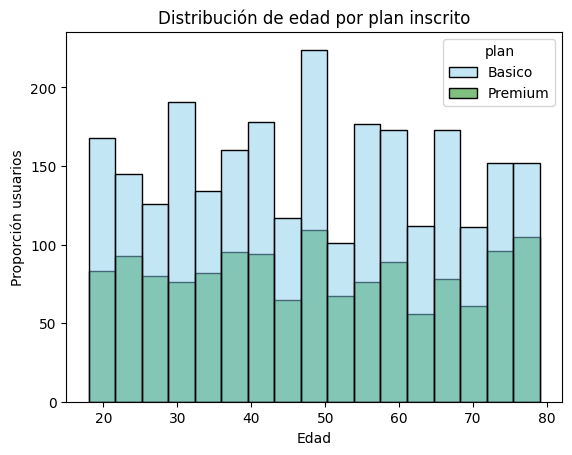

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de edad por plan inscrito')
plt.ylabel('Proporción usuarios')
plt.xlabel('Edad')
plt.show()


💡Insights:
- Se trata de una distribución simétrica concentrando su mayor cantidad de usuarios en la mitad del rango existente (rondando los 50 años).

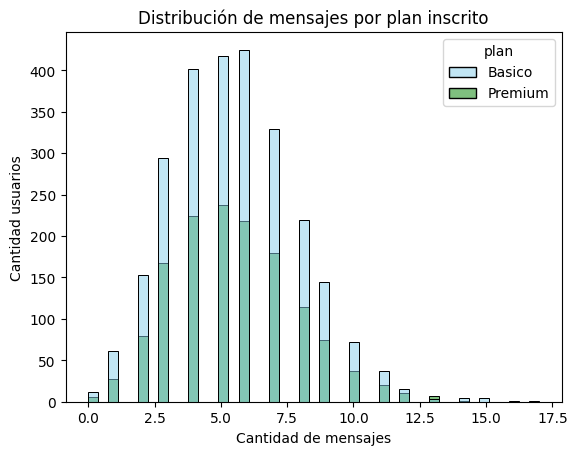

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de mensajes por plan inscrito')
plt.ylabel('Cantidad usuarios')
plt.xlabel('Cantidad de mensajes')
plt.show()

💡Insights:
- Se trata de una distribución sesgada a la derecha lo cual puede elevar el promedio y alejarse de la mediana.

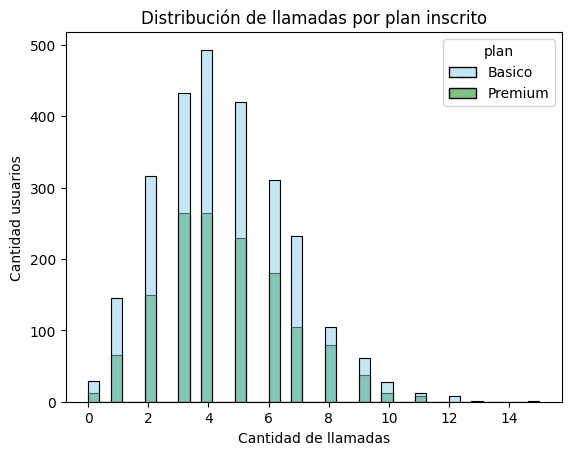

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de llamadas por plan inscrito')
plt.ylabel('Cantidad usuarios')
plt.xlabel('Cantidad de llamadas')
plt.show()

# 💡Insights:
- En la distribución de llamadas continúa el patron de la distribución de texto; el sesgo se mantiene a la derecha.

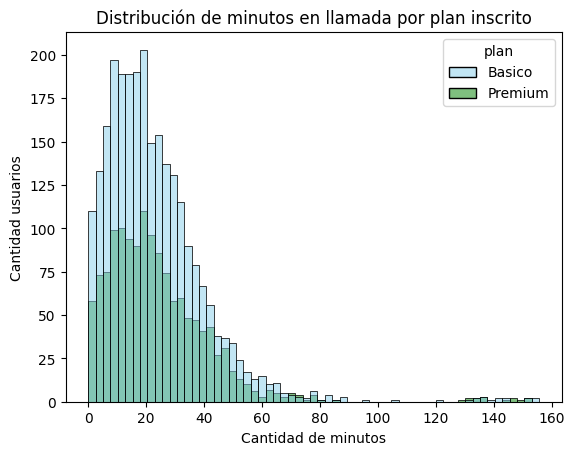

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de minutos en llamada por plan inscrito')
plt.ylabel('Cantidad usuarios')
plt.xlabel('Cantidad de minutos')
plt.show()

💡Insights:
- La distribución de minutos en llamada muestra una cola más alargada que las demás distribuciones.

### 5.2 Identificación de Outliers





🎯 **Objetivo:**  
Detectar valores extremos mediante boxplots en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional. Si hay outliers, calcular los límites de esas columnas usando el **método IQR** y decidir qué hacer con ellos.

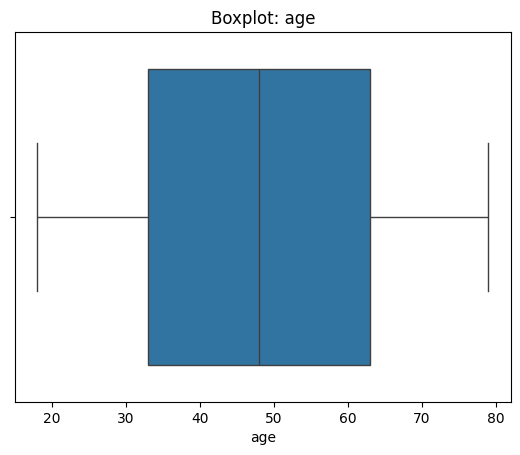

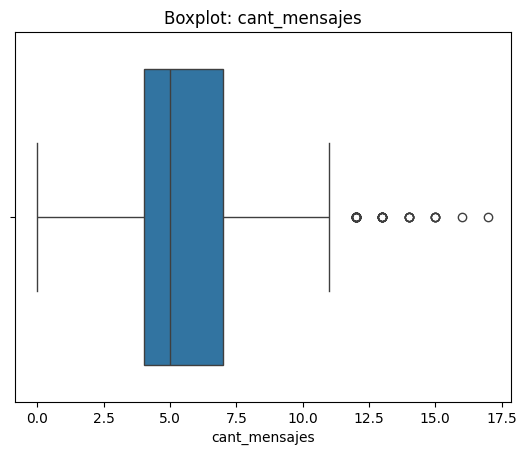

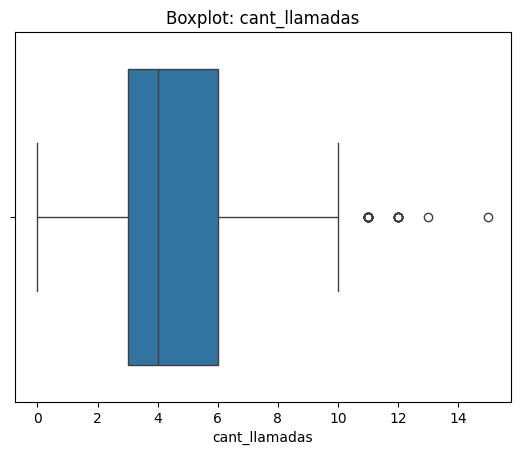

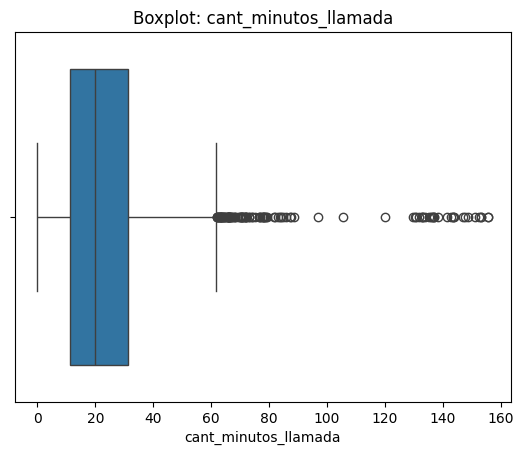

In [34]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [35]:
# Calcular límites con el método IQR


columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
dict_limites = {}
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite = Q3 + 1.5 * IQR
    dict_limites[col] = limite
    print('limite', col,':', limite)


limite cant_mensajes : 11.5
limite cant_llamadas : 10.5
limite cant_minutos_llamada : 61.8575


In [36]:
# Revisar los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes:
   **Se mantendrán los outliers ya que reflejan un comportamiento normal de usuarios. Es más conveniente realizar segmentos para los usuarios que presentan valores muy alejados.**
- cant_llamadas: **Se repite el patrón de cant_mensajes ,por lo que se dará el mismo manejo.**
- cant_minutos_llamada: **La cantidad de outiers aumentó, lo que indica que aún los usuarios nuevos o con pocos servicios utilizados registran largas duraciones en llamadas. De igual manera, se mantendrán los outliers para el analisis.**

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

- `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
- `'Uso medio'` cuando llamadas < 10 y mensajes < 10
- `'Alto uso'` para el resto de casos


In [37]:
# Crear columna grupo_uso
mensajes = user_profile['cant_mensajes']

llamadas = user_profile['cant_llamadas']
user_profile['grupo_uso'] = np.where(
    (mensajes < 5) & (llamadas < 5), 'Bajo uso',
        np.where((mensajes < 10) & (llamadas < 10), 'Uso medio', 'Alto uso')
)

In [38]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.


  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
edad = user_profile['age']
user_profile['grupo_edad'] = np.where(
    edad < 30, 'Joven',
         np.where(edad < 60, 'Adulto', 'Adulto Mayor')
)

In [40]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

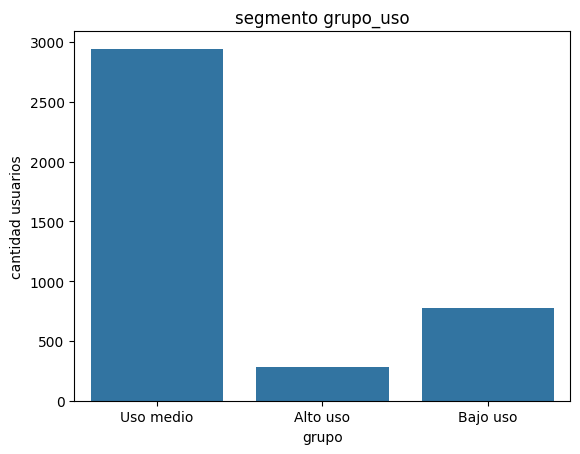

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('segmento grupo_uso')
plt.xlabel('grupo')
plt.ylabel('cantidad usuarios')
plt.show()

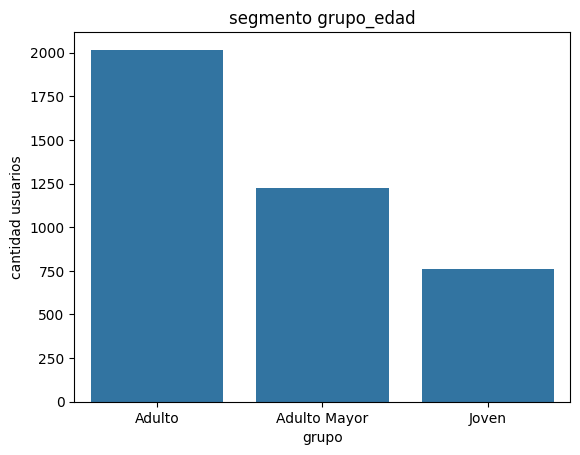

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('segmento grupo_edad')
plt.xlabel('grupo')
plt.ylabel('cantidad usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Se detectaron valores nulos, sentinels, valores no válidos y problemas de formato:
- En la columna city el 11% de los datos son nulos y con sentinels como "?" así como en La columna age la cual contenía sentinels con valores de -999. La columna reg_date contenía un formato que afectaría el analisis así como valores imposibles; valores con año 2026.


🔍 **Segmentos por Edad**
- Se analizó que los usuarios que más utilizan los servicios se encuentran en un rango de edad entre los 30 y 59 años los cuales representan un 50% del total de usuarios.


📊 **Segmentos por Nivel de Uso**
-  El uso medio de servicios predonmina más en este segmento, albergando casi el 75% de los usuarios, los cuales utilizan los servicios de llamada y mensajes entre 5 y 9 veces en general.
- Una cantidad pequeña de usuarios, pueden estar haciendo más uso de los servicios en mayores proporciones que los demás, sin embargo, los gráficos evidencian que en los valores predomina el plan básico.


➡️ Esto sugiere que que no hay mucha variabilidad en cuanto a beneficios entre los tipos de planes, incluso para los usuarios de uso extremo.


💡 **Recomendaciones**
- Revisar y mejorar las funcionalidades del plan premium.
- Realizar campañas de promociones a clientes en el rango de edad entre los 30 y 59 años, por ejemplo reduciendo el costo del plan premium, o reduciendo el costo de textos o minutos progresivamente a su duración o tamaño.